In [1]:
import sys
sys.path.append("..")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from src.evaluate import evaluate_model

with open("../data/processed/processed_data.pkl", "rb") as f:
    data = pickle.load(f)

y_train = data["y_train"]
y_test = data["y_test"]

In [3]:
# Random Forest handles high-dimensional sparse features fine, and unlike KNN
# isn't hurt by mixed scales, so we can use the same Variant A 
# (no Risk_Channel) with TF-IDF text features, for a fair comparison to KNN
X_train = data["A_train_tfidf"]
X_test = data["A_test_tfidf"]

print(X_train.shape, X_test.shape)

(11898, 126) (2975, 126)


In [4]:
# hyperparameter search
# class_weight="balanced" matters here since fraud is only ~15% of data
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5]
}

rf = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)
grid = GridSearchCV(rf, param_grid, scoring="f1", cv=3, n_jobs=-1)
grid.fit(X_train, y_train)

print("best params:", grid.best_params_)
print("best cv f1:", grid.best_score_)

best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
best cv f1: 0.5616345589511278


In [ ]:
# train final model and predict
best_rf = grid.best_estimator_

y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

In [6]:
#evaluate model
results_row, cm = evaluate_model(
    model_name="rf",
    variant="A_tfidf",
    y_test=y_test,
    y_pred=y_pred,
    y_proba=y_proba,
    metrics_path="../results/metrics.csv",
    preds_path="../results/rf_predictions.csv"
)

Accuracy:  0.8894
Precision: 0.6905
Recall:    0.5077
F1-score:  0.5851
ROC-AUC:   0.8508
PR-AUC:    0.6314
Confusion Matrix:
 [[2414  104]
 [ 225  232]]


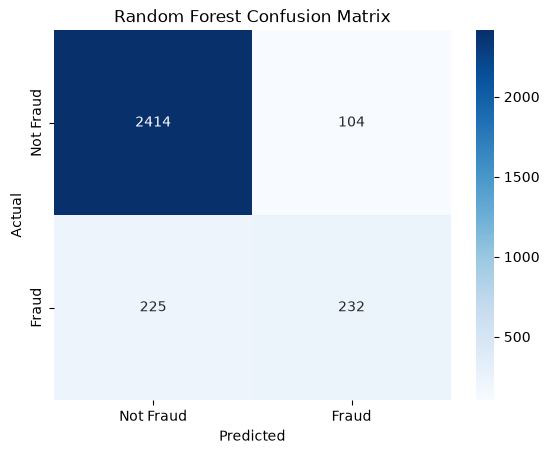

In [7]:
#confusion matrix plot

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"])
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

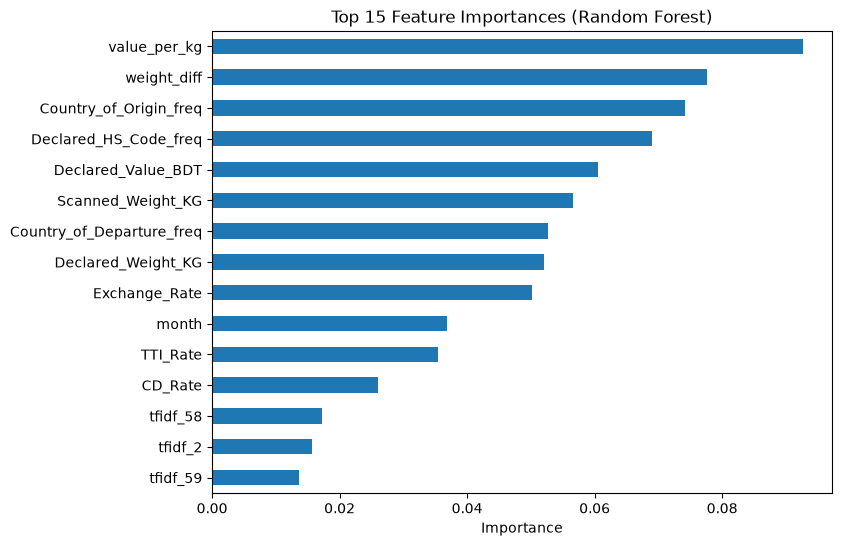

value_per_kg                 0.092611
weight_diff                  0.077585
Country_of_Origin_freq       0.074100
Declared_HS_Code_freq        0.069004
Declared_Value_BDT           0.060496
Scanned_Weight_KG            0.056656
Country_of_Departure_freq    0.052657
Declared_Weight_KG           0.052072
Exchange_Rate                0.050169
month                        0.036909
TTI_Rate                     0.035506
CD_Rate                      0.025987
tfidf_58                     0.017276
tfidf_2                      0.015607
tfidf_59                     0.013643
dtype: float64


In [8]:
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
top_features.plot(kind="barh")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

print(top_features)